## QUEST 4
__Histogram__

In [177]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

database_path = "../data/checking-logs.sqlite"

In [178]:
try:
    connection = sqlite3.connect(database_path)
except Exception:
    print("Не удалось подключиться к СУБД :(")

In [179]:
query = """
select timestamp from checker
where uid like 'user_%'
"""
df = pd.io.sql.read_sql(query, connection, parse_dates="timestamp")

In [180]:
display(df)

,timestamp
0,2020-04-17 05:19:02.744528
1,2020-04-17 05:22:35.249331
2,2020-04-17 05:22:45.549397
3,2020-04-17 05:34:14.691200
4,2020-04-17 05:34:24.422370
...,...
3202,2020-05-21 20:19:06.872761
3203,2020-05-21 20:22:41.785725
3204,2020-05-21 20:22:41.877806
3205,2020-05-21 20:37:00.129678


In [181]:
df["hour"] = df["timestamp"].dt.hour
df_working_day = df[df["timestamp"].dt.dayofweek.apply(lambda x: 1 if x < 5 else 0) == 1]
df_weekend = df[df["timestamp"].dt.dayofweek.apply(lambda x: 1 if x < 5 else 0) == 0]

# df_working_day.drop("timestamp", axis=1, inplace=True)
# df_weekend.drop("timestamp", axis=1, inplace=True)


In [182]:
display(df_working_day)

,timestamp,hour
0,2020-04-17 05:19:02.744528,5
1,2020-04-17 05:22:35.249331,5
2,2020-04-17 05:22:45.549397,5
3,2020-04-17 05:34:14.691200,5
4,2020-04-17 05:34:24.422370,5
...,...,...
3202,2020-05-21 20:19:06.872761,20
3203,2020-05-21 20:22:41.785725,20
3204,2020-05-21 20:22:41.877806,20
3205,2020-05-21 20:37:00.129678,20


In [183]:
display(df_weekend)

,timestamp,hour
23,2020-04-18 07:56:45.408648,7
24,2020-04-18 13:36:53.971502,13
25,2020-04-18 13:42:35.482008,13
26,2020-04-18 13:51:22.291271,13
27,2020-04-18 13:53:17.230725,13
...,...,...
3088,2020-05-17 22:23:05.744415,22
3089,2020-05-17 22:23:11.078664,22
3090,2020-05-17 22:23:11.220412,22
3091,2020-05-17 22:25:15.051189,22


Выведем частоту распределения явно:

In [184]:
working_stats = df_working_day.groupby("hour").count()
working_stats.rename(columns={"timestamp":"commits"}, inplace=True)
display(working_stats)

,commits
hour,
0,6
3,2
5,15
6,3
7,31
8,37
9,30
10,132
11,88


In [185]:
weekend_stats = df_weekend.groupby("hour").count()
weekend_stats.rename(columns={"timestamp":"commits"}, inplace=True)
display(weekend_stats)

,commits
hour,
0,6
1,6
3,1
5,2
7,16
8,28
9,22
10,28
11,118


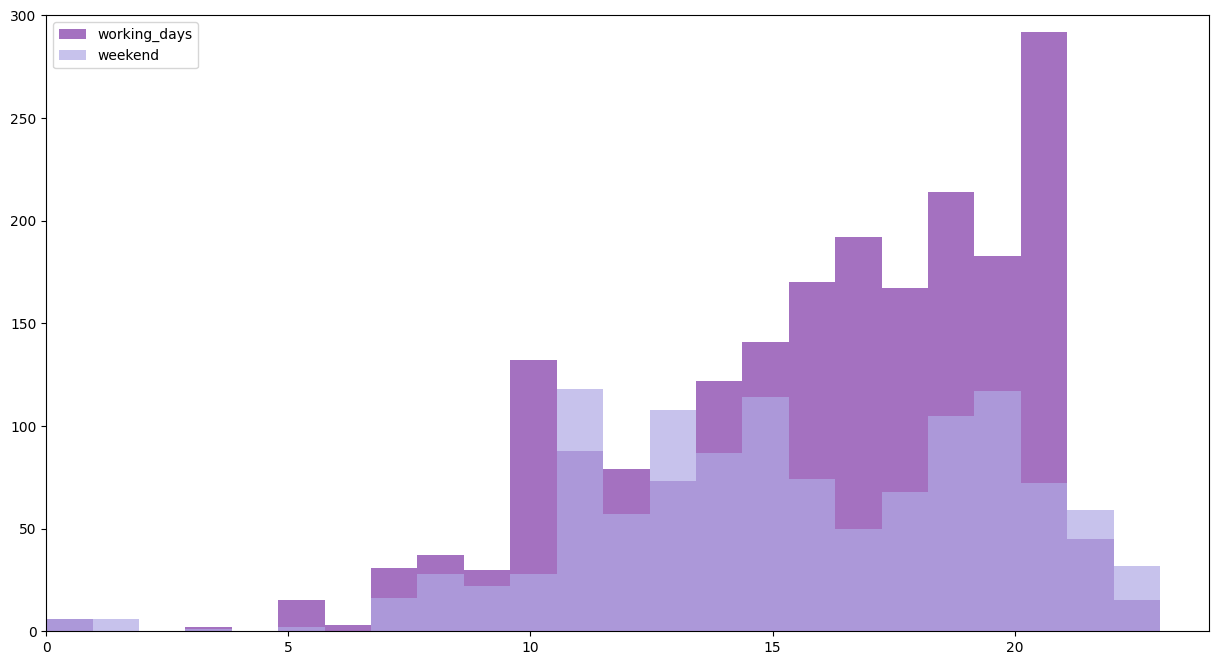

In [186]:
fig, ax = plt.subplots(figsize=(15, 8))
ax.hist(df_working_day["hour"], bins=24, label="working_days", color = "#a471c0")
ax.hist(df_weekend["hour"],
        bins=24,
        label='weekend',
        color="#b0a9e5",
        alpha=0.7)
ax.set_xlim(0, 24)
ax.set_ylim(0,300)
ax.legend(loc='upper left', fontsize='10')
plt.show()

## Are there hours when the total number of commits was higher on weekends than on working days

* put the top-4 examples

* 1 am
* 11 am
* 1 pm
* 10 pm
-------------
* 11 pm

Проверим кодом:

In [187]:
all_days = working_stats.merge(weekend_stats, on="hour", how="outer").fillna(0)

In [188]:

display(all_days[all_days["commits_x"] < all_days["commits_y"]])

,commits_x,commits_y
hour,,
11,88.0,118.0
13,73.0,108.0
22,45.0,59.0
23,15.0,32.0
1,0.0,6.0


In [189]:
connection.close()